### Mar 11 quadratic zeeman

In [1]:
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt
from uncertainties import ufloat, unumpy

import Methods as m
import importlib
importlib.reload(m)

<module 'Methods' from '/Users/markzhitnitsky/Desktop/School/2025-26 Year/PHYS409/Experiment 2 - Optical Pumping/Code/Methods.py'>

In [2]:
freq = 8.83
date = "Mar 23"
vHoriz = 1.094 # V
savename = "10s measurement " + date + " - " + str(freq).replace('.', 'p') + "MHz"
# time, y1, y2, y2_norm = m.read_transmission_csv("./data/" + date + " measurement/" + str(freq).replace('.', 'p') + "MHz_10s_" + str(vHoriz).replace('.', 'p') + ".csv")
time, y1, y2, y2_norm = m.read_transmission_csv("./data/" + date + " measurement/" + str(freq).replace('.', 'p') + "MHz_" + str(vHoriz).replace('.', 'p') + "V.csv")
# time, y1, y2, y2_norm = m.read_transmission_csv("./data/" + date + " measurement/" + str(freq).replace('.', 'p') + "MHz_10s.csv")
# vHoriz = (vHoriz) / 1000
vShift = ufloat(vHoriz,0.0001)

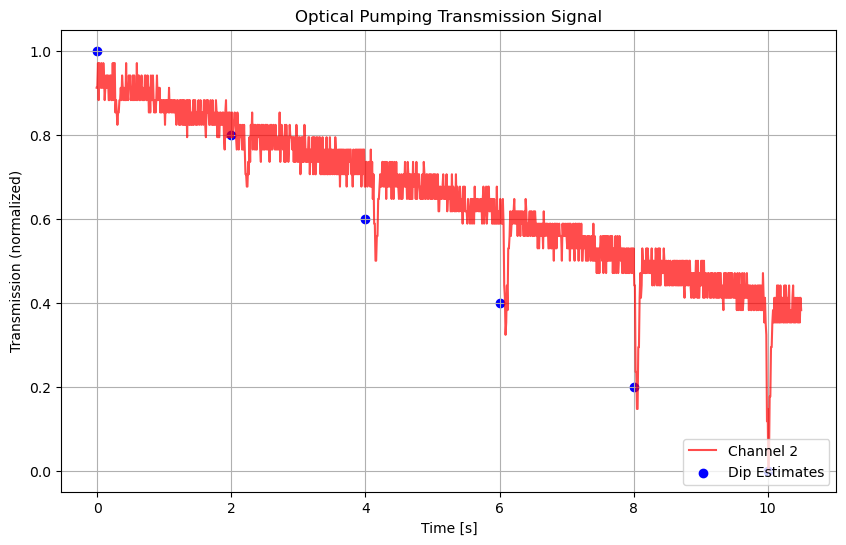

In [3]:
t0 = 0.5
tf = 11
nCutBeginning = (t0 // (time[1] - time[0])).astype(int)
nCutEnd = ((time[-1] - tf) // (time[1] - time[0])).astype(int)

time_cutFirst = time[nCutBeginning:len(time)-nCutEnd] - t0
y2_norm_cutFirst = y2_norm[nCutBeginning:len(time)-nCutEnd]

x0s = np.array([0,2,4,6,8,10])

m.plot_quadraticZeeman_sextuple_transmission(time_cutFirst, y2_norm_cutFirst, x0s, savename)

In [4]:
#    (A, h1, g1, x0_1, h2, g2, x0_2,  h3, g3, x0_3):
variables = ["A", "m", "h1", "g1", "x0_1", "h2", "g2", "x0_2",  "h3", "g3", "x0_3",  "h4", "g4", "x0_4",  "h5", "g5", "x0_5",  "h6", "g6", "x0_6"]
p0 = (1, -0.02, 0.2, 0.3, x0s[0], 0.3, 0.1, x0s[1], 0.5, 0.1, x0s[2], 0.5, 0.1, x0s[3], 0.5, 0.1, x0s[4], 0.5, 0.1, x0s[5])
lower_bound = (0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0)
upper_bound = (2,0,2,2,1,2,2,3,2,2,5,2,2,7,2,2,9,2,2,11)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.sextuple_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
for val, name in zip(popt,variables):
    print(name, val)

A 0.9305577311617305
m -0.052865271312465587
h1 0.08976265401315624
g1 0.017065060964268155
x0_1 0.30255110135670765
h2 0.14071115505529164
g2 0.025792410506818804
x0_2 2.2323707045299526
h3 0.22366665216356604
g3 0.021328455090303195
x0_3 4.1578101054749625
h4 0.28939538998312037
g4 0.021251134447413538
x0_4 6.096096623359792
h5 0.3810493058076529
g5 0.021716794083006825
x0_5 8.053119136451174
h6 0.40818708780513574
g6 0.02104331358280822
x0_6 10.013765376115314


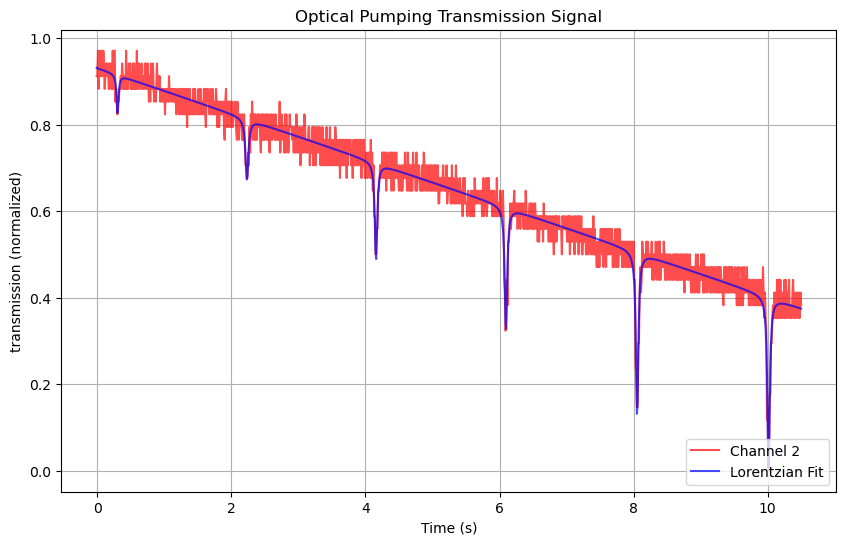

In [5]:
m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.sextuple_lorentz, "fit to " + savename)


In [6]:
x0_1_u = ufloat(popt[4],  perr[4]) + t0
x0_2_u = ufloat(popt[7],  perr[7]) + t0
x0_3_u = ufloat(popt[10], perr[10]) + t0
x0_4_u = ufloat(popt[13], perr[13]) + t0
x0_5_u = ufloat(popt[16], perr[16]) + t0
x0_6_u = ufloat(popt[19], perr[19]) + t0

dt = time[1] - time[0]
x0_1_index = int(x0_1_u.n // dt)
x0_2_index = int(x0_2_u.n // dt)
x0_3_index = int(x0_3_u.n // dt)
x0_4_index = int(x0_4_u.n // dt)
x0_5_index = int(x0_5_u.n // dt)
x0_6_index = int(x0_6_u.n // dt)

numAvg = 10


# vMeasured =0.3045  # V
# TODO: adjust this, I assumed 0.2% ucnertainty from seeing how much the smaller digits varied at a constant measurement

v_0Field = ufloat(0.30,0.0034) # taken from 25kHz, though other frequencies were close (this isn't frequency dependent)

v_1 = ufloat(np.mean(y1[x0_1_index - numAvg : x0_1_index + numAvg]),
             np.std(y1[x0_1_index - numAvg : x0_1_index + numAvg]))
v_2 = ufloat(np.mean(y1[x0_2_index - numAvg : x0_2_index + numAvg]),
             np.std(y1[x0_2_index - numAvg : x0_2_index + numAvg]))
v_3 = ufloat(np.mean(y1[x0_3_index - numAvg : x0_3_index + numAvg]),
             np.std(y1[x0_3_index - numAvg : x0_3_index + numAvg]))
v_4 = ufloat(np.mean(y1[x0_4_index - numAvg : x0_4_index + numAvg]),
             np.std(y1[x0_4_index - numAvg : x0_4_index + numAvg]))
v_5 = ufloat(np.mean(y1[x0_5_index - numAvg : x0_5_index + numAvg]),
             np.std(y1[x0_5_index - numAvg : x0_5_index + numAvg]))
v_6 = ufloat(np.mean(y1[x0_6_index - numAvg : x0_6_index + numAvg]),
             np.std(y1[x0_6_index - numAvg : x0_6_index + numAvg]))

# VtoBSweep = ufloat(0.6 * 10 ** (-4) , 0.6 * 10 ** (-4)  / 100) * 1.03360784475
# VtoBHoriz = ufloat(1.705174,0.028108) / 1000
VtoBSweep = ufloat(6.20693,0.03559)*10**(-5) # new VtoB from Mar 23rd
# VtoBHoriz = ufloat(1.730183,0.033567) / 1000 # from mar23
VtoBHoriz = VtoBSweep * ufloat(27.731,0.047) # new from Mar25

print(f"VtoBHoriz: {VtoBHoriz:.2ue}")

dip1 = (v_1-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip2 = (v_2-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip3 = (v_3-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip4 = (v_4-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip5 = (v_5-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip6 = (v_6-v_0Field) * VtoBSweep + vShift * VtoBHoriz

print(f"B field of dip 1: {dip1:.3e}")
print(f"B field of dip 2: {dip2:.3e}")
print(f"B field of dip 3: {dip3:.3e}")
print(f"B field of dip 4: {dip4:.3e}")
print(f"B field of dip 5: {dip5:.3e}")
print(f"B field of dip 6: {dip6:.3e}")

B field of dip 1: (1.867+/-0.011)e-03
B field of dip 2: (1.878+/-0.011)e-03
B field of dip 3: (1.889+/-0.011)e-03
B field of dip 4: (1.900+/-0.011)e-03
B field of dip 5: (1.911+/-0.011)e-03
B field of dip 6: (1.923+/-0.011)e-03


In [7]:
filepath = 'models/quadraticRb85ZeemanData.csv'

m.append_to_sextupleZeeman_csv(freq, (dip1,dip2,dip3,dip4,dip5,dip6), filepath)

In [8]:
freq = 8.8
date = "Mar 23"
vHoriz = 731.2 # V
savename = "10s measurement " + date + " - " + str(freq).replace('.', 'p') + "MHz"
time, y1, y2, y2_norm = m.read_transmission_csv("./data/" + date + " measurement/" + str(freq).replace('.', 'p') + "MHz_" + str(vHoriz).replace('.', 'p') + "mV.csv")
vHoriz = vHoriz / 1000

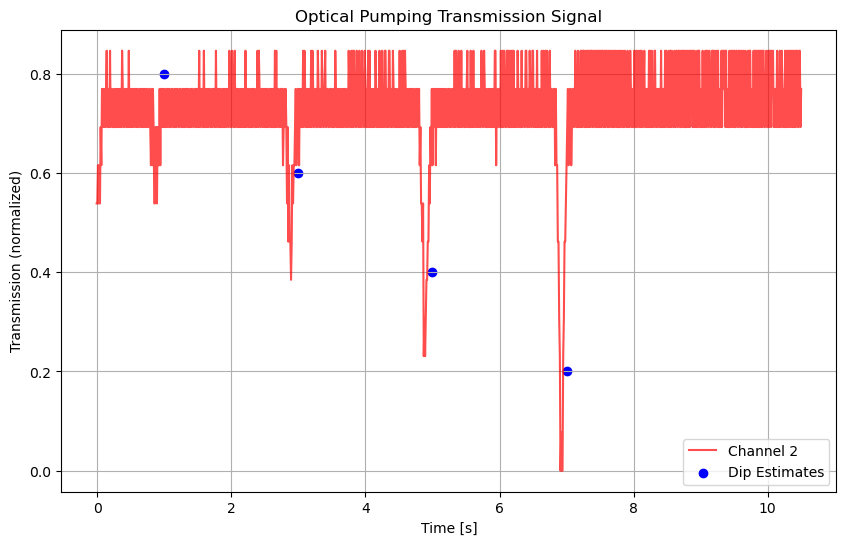

In [9]:
t0 = 0.5
tf = 11
nCutBeginning = (t0 // (time[1] - time[0])).astype(int)
nCutEnd = ((time[-1] - tf) // (time[1] - time[0])).astype(int)

time_cutFirst = time[nCutBeginning:len(time)-nCutEnd] - t0
y2_norm_cutFirst = y2_norm[nCutBeginning:len(time)-nCutEnd]

x0s = np.array([1,3,5,7])

m.plot_quadraticZeeman_quadruple_transmission(time_cutFirst, y2_norm_cutFirst, x0s, savename)

In [10]:
#    (A, h1, g1, x0_1, h2, g2, x0_2,  h3, g3, x0_3):
variables = ["A", "m", "h1", "g1", "x0_1", "h2", "g2", "x0_2",  "h3", "g3", "x0_3",  "h4", "g4", "x0_4"]
p0 = (1, -0.02, 1, 0.1, x0s[0], 0.3, 0.1, x0s[1], 0.5, 0.1, x0s[2], 0.5, 0.1, x0s[3])
lower_bound = (0,-1,0,0,0,0,0,0,0,0,0,0,0,0)
upper_bound = (2,0,2,2,10,2,2,10,2,2,10,2,2,10)

# print(len(p0))
# print(len(variables))
# print(len(lower_bound))
# print(len(upper_bound))

bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.quadruple_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
for val, name in zip(popt,variables):
    print(name, val)

A 0.7511597320603494
m -7.86989081940915e-37
h1 0.12724092595557854
g1 0.06788457669763982
x0_1 0.872718947423853
h2 0.31993291809248614
g2 0.03782689278160552
x0_2 2.8847951310674715
h3 0.50404643321259
g3 0.04095503618624537
x0_3 4.891348050032465
h4 0.8007054086201508
g4 0.034251080821162655
x0_4 6.9257631278043865


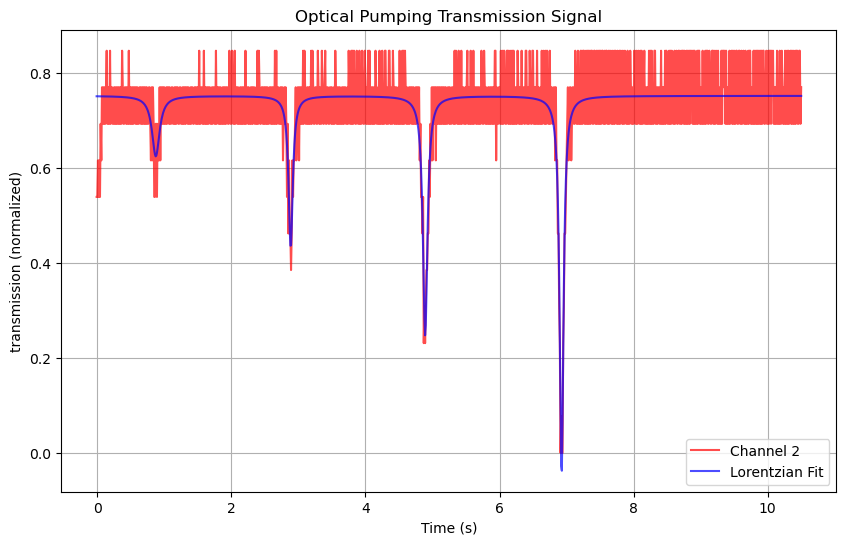

In [11]:
m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.quadruple_lorentz, "fit to " + savename)


In [13]:
x0_1_u = ufloat(popt[4],  perr[4]) + t0
x0_2_u = ufloat(popt[7],  perr[7]) + t0
x0_3_u = ufloat(popt[10], perr[10]) + t0
x0_4_u = ufloat(popt[13], perr[13]) + t0

dt = time[1] - time[0]
x0_1_index = int(x0_1_u.n // dt)
x0_2_index = int(x0_2_u.n // dt)
x0_3_index = int(x0_3_u.n // dt)
x0_4_index = int(x0_4_u.n // dt)

numAvg = 10

vShift = ufloat(vHoriz,0.00001) # range shifted, either get from data or write down dial position idk
# TODO: adjust this, I assumed 0.2% ucnertainty from seeing how much the smaller digits varied at a constant measurement

v_0Field = ufloat(0.3,0.0034) # taken from 25kHz, though other frequencies were close (this isn't frequency dependent)

v_1 = ufloat(np.mean(y1[x0_1_index - numAvg : x0_1_index + numAvg]),
             np.std(y1[x0_1_index - numAvg : x0_1_index + numAvg]))
v_2 = ufloat(np.mean(y1[x0_2_index - numAvg : x0_2_index + numAvg]),
             np.std(y1[x0_2_index - numAvg : x0_2_index + numAvg]))
v_3 = ufloat(np.mean(y1[x0_3_index - numAvg : x0_3_index + numAvg]),
             np.std(y1[x0_3_index - numAvg : x0_3_index + numAvg]))
v_4 = ufloat(np.mean(y1[x0_4_index - numAvg : x0_4_index + numAvg]),
             np.std(y1[x0_4_index - numAvg : x0_4_index + numAvg]))

# VtoBSweep = ufloat(0.6 * 10 ** (-4) , 0.6 * 10 ** (-4)  / 100) * 1.03360784475
# VtoBHoriz = ufloat(1.705174,0.028108) / 1000
VtoBSweep = ufloat(6.20693,0.03559)*10**(-5) # new VtoB from Mar 23rd
# VtoBHoriz = ufloat(1.730183,0.033567) / 1000 # from mar23
VtoBHoriz = VtoBSweep * ufloat(27.731,0.047) # new from Mar25

print(f"VtoBHoriz: {VtoBHoriz:.2ue}")

dip1 = (v_1-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip2 = (v_2-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip3 = (v_3-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip4 = (v_4-v_0Field) * VtoBSweep + vShift * VtoBHoriz

print(f"B field of dip 1: {dip1:.3e}")
print(f"B field of dip 2: {dip2:.3e}")
print(f"B field of dip 3: {dip3:.3e}")
print(f"B field of dip 4: {dip4:.3e}")

VtoBHoriz: (1.721+/-0.010)e-03
B field of dip 1: (1.254+/-0.008)e-03
B field of dip 2: (1.257+/-0.008)e-03
B field of dip 3: (1.260+/-0.008)e-03
B field of dip 4: (1.263+/-0.008)e-03


In [79]:
filepath = 'models/quadraticRb87ZeemanData.csv'

m.append_to_quadrupleZeeman_csv(freq, (dip1,dip2,dip3,dip4), filepath)